<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
     Datos de un archivo NetCDF
  </span>
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema : Uso de librería xarray para un archivo NetCDF en Python</span><br/>
  <span style="font-size:100%;color:forestgreen"> Curso Dinámica del Clima  |  Semestre 2027-I</span>
</p>

---


Un archivo NetCDF (.nc, Network Common Data Form) es un formato binario, utilizado en meteorología y oceanografía para almacenar matrices multidimensionales.

Vincula directamente los datos físicos con su ubicación espacio-temporal mediante cuatro componentes fundamentales:


|Componentes     | Tipo |Aplicación                           |
|---------|---------|-------------------------------------|
|`Dimensiones`    | time, latitude, longitude  | time = 24 , lat = 14, lon = 116  |
|`Coordenadas`  | time, latitude, longitude    | time = 00:00, 01:00, ... latitude = 20, 20.25, ... longitude = -115, -114.75, ...|
|`Variables`| u10, v10, T, SST, TP  |      |
|`Atributos`    | Unidades, proyección cartográfica, fuente del dataset | |

La librería xarray es la herramienta estándar para manejar datos climatológicos en Python.

# **<font color="ForestGreen">  Acceso a datos </font>**

In [1]:
import xarray as xr

# librería para importar archivos en google colab
# from google.colab import files 


### **<font color="ForestGreen"> Para importar datos en Google Colab </font>**

```python
uploaded = files.upload() # aqui subes su archivo

data_1 = list(uploaded.keys())[0] # uploaded es un diccionario. Para no cargar con el nombre completo del archivo lo guardamos en lavariable data_1

dl = xr.open_dataset(data_1) # accedemos al archivo .nc con la libreria xarray
print(dl)

In [2]:
ds = xr.open_dataset("reanalysis-era5-single-levels-timeseries-sfc8egh6gpz.nc")
print(ds)

/home/jair/miniconda3/envs/oceanography/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 140kB
Dimensions:     (valid_time: 8760)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    u10         (valid_time) float32 35kB ...
    v10         (valid_time) float32 35kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts


# **<font color="ForestGreen">  Inspeccionando el dataset </font>**

In [3]:
print("Dimensiones:", ds.dims) # visualizar dimensipnes
print("Coordenadass:", ds.coords)

Dimensiones: FrozenMappingWarningOnValuesAccess({'valid_time': 8760})
Coordenadass: Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
    latitude    float64 8B ...
    longitude   float64 8B ...


In [4]:
ds.valid_time.values

array(['2023-01-01T00:00:00.000000000', '2023-01-01T01:00:00.000000000',
       '2023-01-01T02:00:00.000000000', ...,
       '2023-12-31T21:00:00.000000000', '2023-12-31T22:00:00.000000000',
       '2023-12-31T23:00:00.000000000'],
      shape=(8760,), dtype='datetime64[ns]')

In [5]:
ds.u10.values # visualizar datos

array([-2.672058  , -2.9454498 , -2.5686646 , ..., -0.12800598,
       -0.3190918 , -1.3061981 ], shape=(8760,), dtype=float32)

In [6]:
u10 = ds["u10"] # lo guardamos como un metadato

In [66]:
# guardamos los datos de componente del viento en E-O en la variable u10.

u10 = ds["u10"].values
v10 = ds["v10"].values

In [8]:
u10[50]

np.float32(-2.1369934)

In [9]:
v10[30:55]

array([ 2.4693909 ,  3.263977  ,  2.6529999 ,  1.6563721 ,  1.0482788 ,
        0.8542633 ,  0.3665161 , -0.85098267, -1.1104736 , -0.95129395,
       -1.1817017 , -2.294464  , -2.5711212 , -2.6183624 , -2.6109009 ,
       -3.5919342 , -2.893921  , -3.1047058 , -3.8036652 , -3.48674   ,
       -3.161377  , -3.0182648 , -2.760025  , -2.8188477 , -2.361435  ],
      dtype=float32)

In [10]:
len(u10)

8760

In [11]:
min(v10)

np.float32(-11.417236)

# **<font color="ForestGreen">  Datos de viento zonal y meridional </font>**

In [12]:
import matplotlib.pyplot as plt

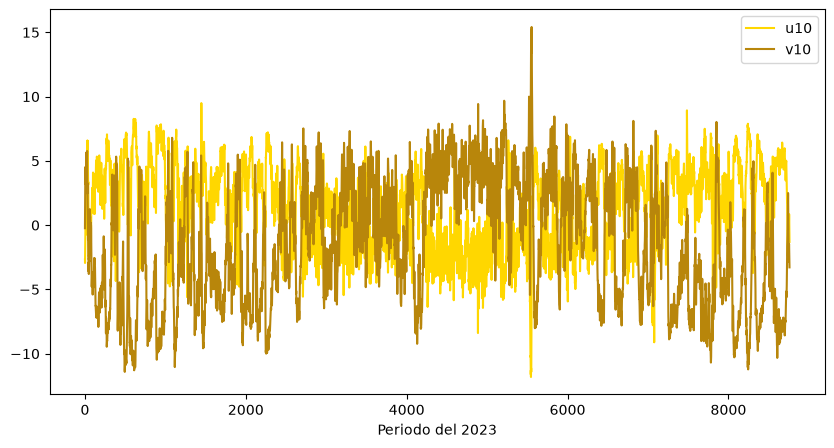

In [13]:
# Graficando las componentes u10 y v10

plt.figure(figsize=(10,5))

plt.plot(u10, color = "gold", label = "u10")
plt.plot(v10, color = "darkgoldenrod", label = "v10")


plt.xlabel("Periodo del 2023")
plt.legend()
plt.show()

In [14]:
u10_reshape = u10.reshape(365,24) # redimensionamos reshape(filas, col)
v10_reshape = v10.reshape(365,24)

In [15]:
len(u10_reshape)

365

In [16]:
u10_reshape[0] # corresponde al priemro de enero del 2023. Este elemento tiene a su vez 24 elementos correspondientes a las 24 horas


array([-2.672058  , -2.9454498 , -2.5686646 , -1.8116455 , -1.0690155 ,
       -0.60061646, -0.28536987,  0.07063293,  0.43782043,  0.6799469 ,
        0.26124573,  0.345932  ,  0.8631134 ,  1.0741272 ,  1.184021  ,
        1.1270142 ,  1.4432678 ,  1.6277618 ,  1.9571381 ,  1.8751831 ,
        0.96733093,  0.12322998, -0.18583679, -0.7283325 ], dtype=float32)

In [17]:
import numpy as np

In [18]:
# ccreamos dos arreglos de ceros con las mismas dimensiones

u10_mean = np.zeros((365,1))

v10_mean = np.zeros((365,1))

In [19]:
for i in range(0,365):
    u10_mean[i] = np.mean(u10_reshape[i])
    v10_mean[i] = np.mean(v10_reshape[i])

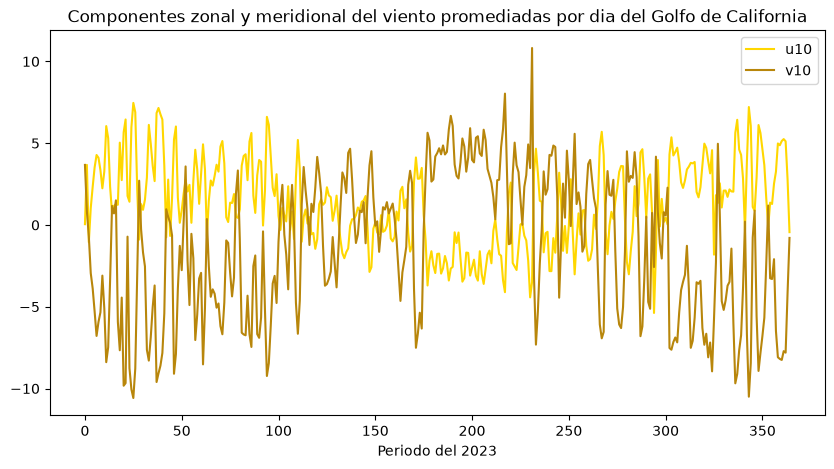

In [20]:
# Graficando las componentes u10 y v10 promediadad por dia

plt.figure(figsize=(10,5))

plt.plot(u10_mean, color = "gold", label = "u10")
plt.plot(v10_mean, color = "darkgoldenrod", label = "v10")


plt.title("Componentes zonal y meridional del viento promediadas por dia del Golfo de California")
plt.xlabel("Periodo del 2023")
plt.legend()
plt.show()

# **<font color="ForestGreen">  Serie temporal de viento en un punto geografico </font>**

Ambas variables del viento solamente dependen de la variable tiempo

| `u10 = u10(t)`  | 
|  `v10 = v10(t)` | 


In [21]:
# creamos el vector viento

wind = np.zeros((365,2))

In [22]:
for i in range(0,365):
    wind[i,0] = u10_mean[i,0] # para asignar una variable de dos elementos tambien hay que asignar la otra variable de la misma dimension
    wind[i,1] = v10_mean[i,0]

In [23]:
len(u10_mean)

365

In [24]:
wind

array([[ 4.87823486e-02,  3.67333221e+00],
       [ 3.67440867e+00,  8.25170517e-01],
       [-1.05444205e+00, -6.92840576e-01],
       [ 1.04327333e+00, -2.94747281e+00],
       [ 2.33949161e+00, -3.88722491e+00],
       [ 3.52193069e+00, -5.29485893e+00],
       [ 4.27906656e+00, -6.78378534e+00],
       [ 4.10718393e+00, -5.92757082e+00],
       [ 3.35151672e+00, -5.33851051e+00],
       [ 2.24294734e+00, -3.09704328e+00],
       [ 3.27180219e+00, -5.10478592e+00],
       [ 6.04655886e+00, -8.38904476e+00],
       [ 5.31199265e+00, -7.47647858e+00],
       [ 2.33405757e+00, -3.34419823e+00],
       [ 7.25549698e-01,  1.16637802e+00],
       [ 1.17905104e+00,  7.06432343e-01],
       [ 1.25188959e+00,  1.50505960e+00],
       [ 1.23548830e+00, -5.92692995e+00],
       [ 5.03417540e+00, -7.66098928e+00],
       [ 2.74338841e+00, -4.43918657e+00],
       [ 5.66677237e+00, -9.82906342e+00],
       [ 6.45182562e+00, -9.66840935e+00],
       [ 1.77611542e+00, -7.14307129e-01],
       [ 1.

/tmp/ipykernel_24794/1207108276.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


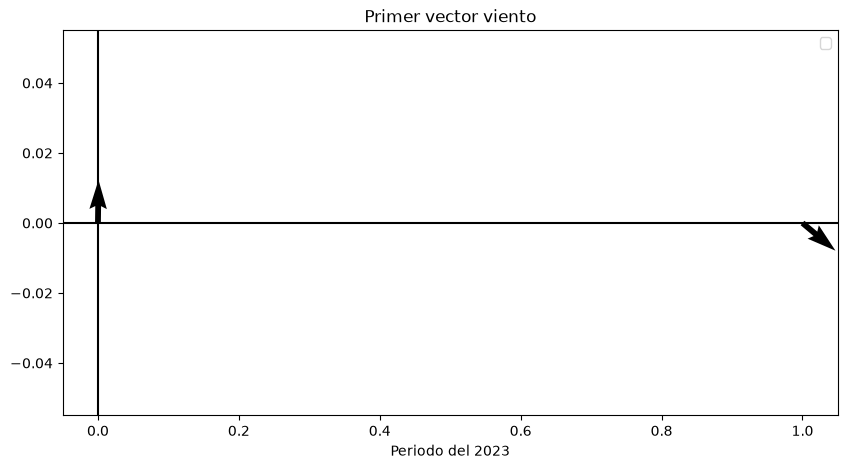

In [ ]:
# graficar el pimer vector viento


plt.figure(figsize=(10,5))

plt.quiver(0,0, wind[0,0],wind[0,1]) #quiver(origen_x, origen_x, corrd_x, coord_y)
plt.quiver(1, 0, wind[1,1], wind[2,1])

plt.axhline(y = 0.0, color = "black")
plt.axvline(x = 0.0, color = "black")

plt.title("Primer vector viento")
plt.xlabel("Periodo del 2023")
plt.legend()
plt.show()

/tmp/ipykernel_24794/3763389866.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


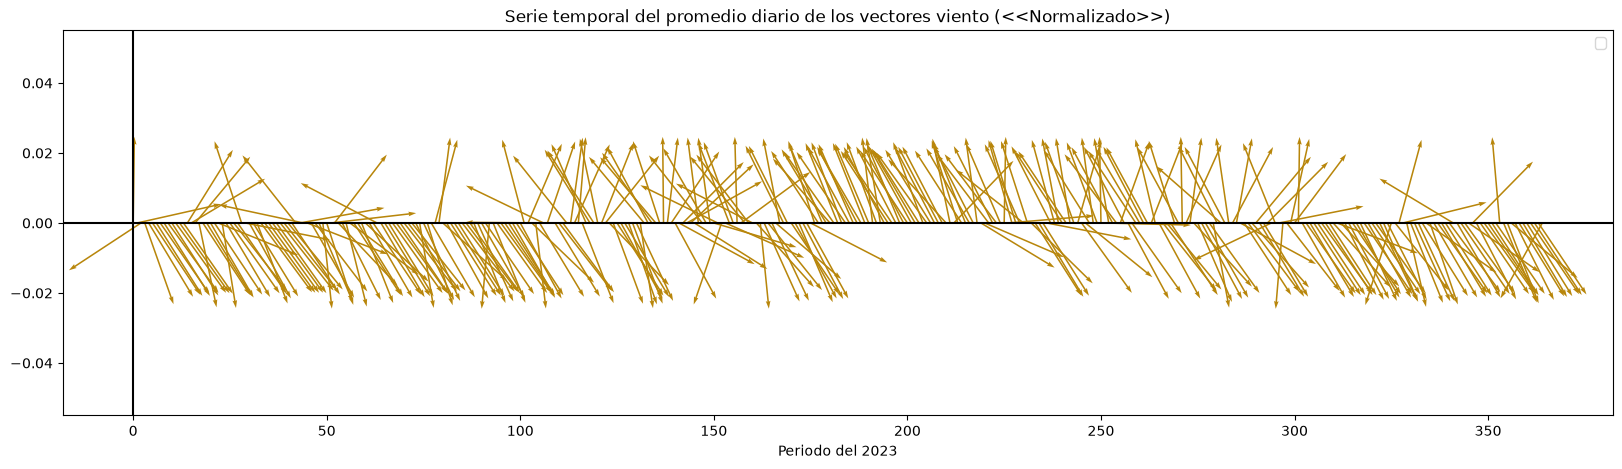

In [41]:
# graficar el pimer vector viento

plt.figure(figsize=(20,5))

for i in range(0, len(wind)):
    plt.quiver(i,0, wind[i,0],wind[i,1], width = 0.001, color = "darkgoldenrod") #quiver(origen_x, origen_x, corrd_x, coord_y)    #variamos la coordenada x


plt.axhline(y = 0.0, color = "black")
plt.axvline(x = 0.0, color = "black")

plt.title("Serie temporal del promedio diario de los vectores viento (<<Normalizado>>)")
plt.xlabel("Periodo del 2023")
plt.legend()
plt.show()

# ¿Qué está haciendo python internamente para normalizarlos?

/tmp/ipykernel_24794/106133654.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


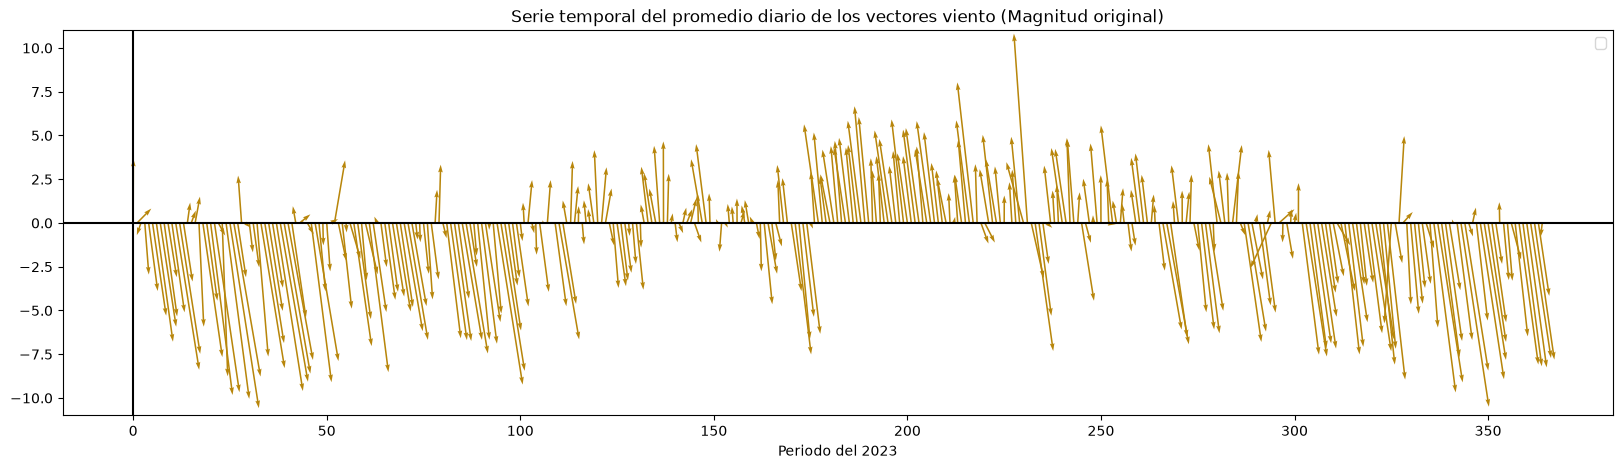

In [ ]:
# graficar el pimer vector viento

plt.figure(figsize=(20,5))

for i in range(0, len(wind)):
    plt.quiver(i,0, wind[i,0],wind[i,1], width = 0.001, color = "darkgoldenrod", scale = 1, angles = "xy", scale_units = "xy") #quiver(origen_x, origen_x, corrd_x, coord_y)    
    #variamos la coordenada x


plt.axhline(y = 0.0, color = "black")
plt.axvline(x = 0.0, color = "black")

plt.title("Serie temporal del promedio diario de los vectores viento (Magnitud original)")
plt.xlabel("Periodo del 2023")

plt.ylim(-11,11)
plt.legend()
plt.show()

# ¿De dónde vienen esos vientos?

# **<font color="ForestGreen">  Promedio Móvil </font>**

In [ ]:
def function1(x):
    resutaldo = x**2
    return resutaldo

In [43]:
function1(8)

64

In [68]:
# construir una función para calcular el promedio móvil 

def movil(array, ventana):

    array_movil = array

    nuevo_array = np.zeros(len(array)- ventana) # las dimensiones en general depende del archivo

    c = 0

    for i in range(len(array)-ventana): # aqui nos colocamos en un elemento fijo

        p = np.zeros(ventana) # arreglo para meter los promedios 

        for j in range(ventana):
            
            p[j] = array_movil[j + c] # actualizamos el arreglo p con los valores del arreglo a calcular el promedio movil

        k = np.mean(p) # calculamos el promedio del arreglo p
        nuevo_array[i] = k

        c = c+1 # actualizar el contador c para seguir al siguente valor del arreglo original

    return nuevo_array

In [71]:
movil_u10 = movil(u10, 24)
movil_v10 = movil(v10, 24)

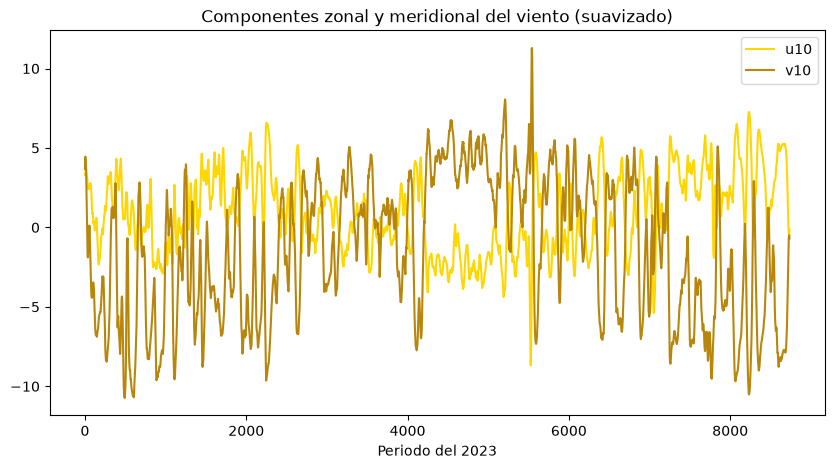

In [75]:
# Graficando las componentes u10 y v10

plt.figure(figsize=(10,5))

plt.plot(movil_u10, color = "gold", label = "u10")
plt.plot(movil_v10, color = "darkgoldenrod", label = "v10")


plt.title("Componentes zonal y meridional del viento (suavizado)")
plt.xlabel("Periodo del 2023")
plt.legend()
plt.show()

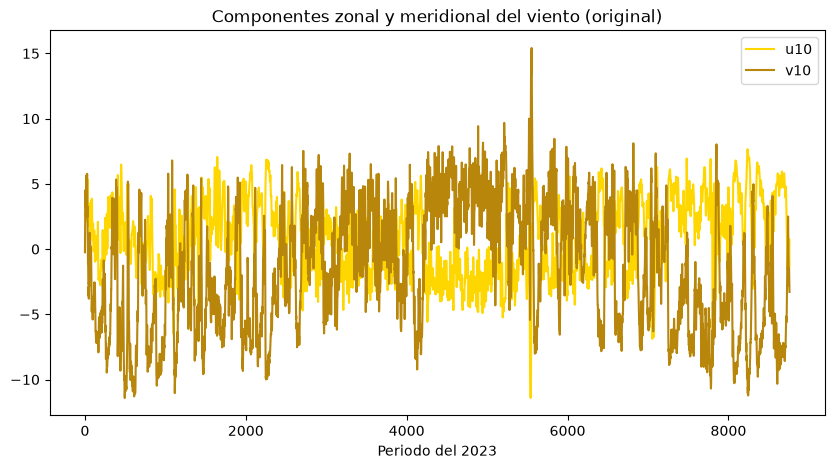

In [76]:
# Graficando las componentes u10 y v10

plt.figure(figsize=(10,5))

plt.plot(u10, color = "gold", label = "u10")
plt.plot(v10, color = "darkgoldenrod", label = "v10")


plt.xlabel("Periodo del 2023")
plt.title("Componentes zonal y meridional del viento (original)")
plt.legend()
plt.show()

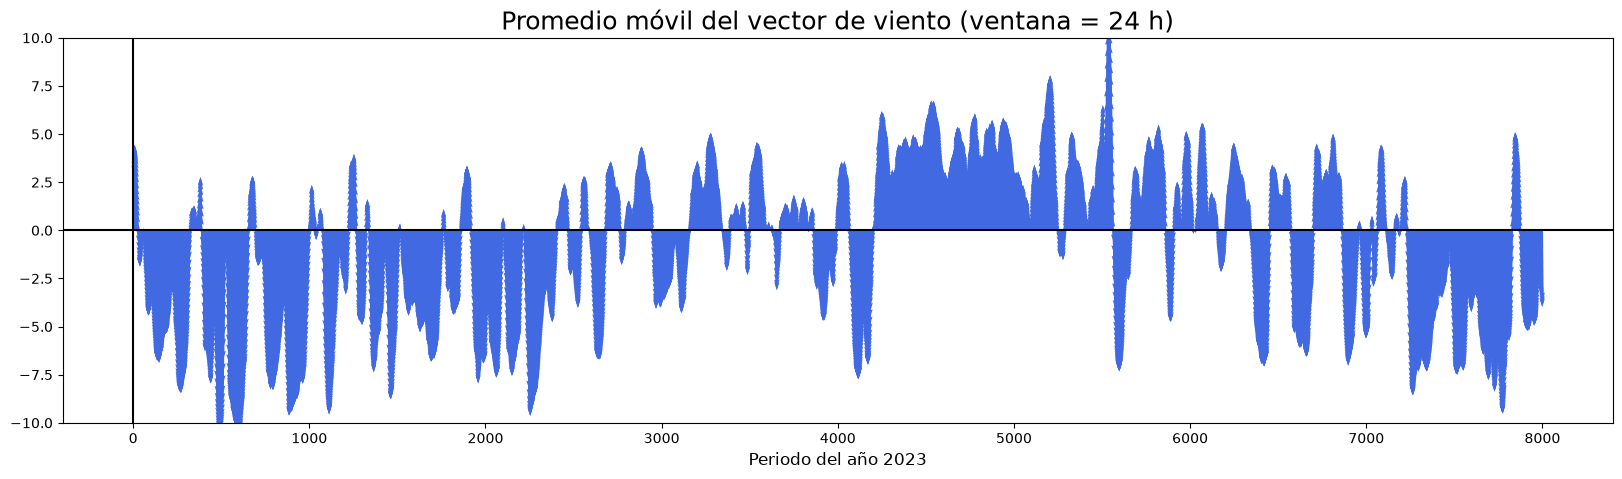

In [77]:
promedio_movil_u10 = movil(u10,24)

promedio_movil_v10 = movil(v10,24)

# creamos el vector viento.

# Notemos que el vector wind contiene 365 datos, cada componente promediada.
# Este vector esta en el sistema de referecnia N-S.

wind_movil = np.zeros((len(promedio_movil_u10),2)) 

for i in range(0,len(promedio_movil_u10)):
  wind_movil[i,0] = promedio_movil_u10[i]
  wind_movil[i,1] = promedio_movil_v10[i]

plt.figure(figsize=(20,5))

for i in range(0,8000):
  plt.quiver(i,0,wind_movil[i,0],wind_movil[i,1], width = 0.001, color = 'royalblue',scale = 1, angles = 'xy', scale_units = 'xy')

plt.axhline(y = 0.0, xmin = 0.0, color = 'black')
plt.axvline(x = 0.0, ymin = 0.0, color = 'black')

# plt.grid()
plt.title("Promedio móvil del vector de viento (ventana = 24 h)", fontsize = 18)
plt.xlabel("Periodo del año 2023", fontsize = 12)

plt.ylim(-10,10)
plt.show()

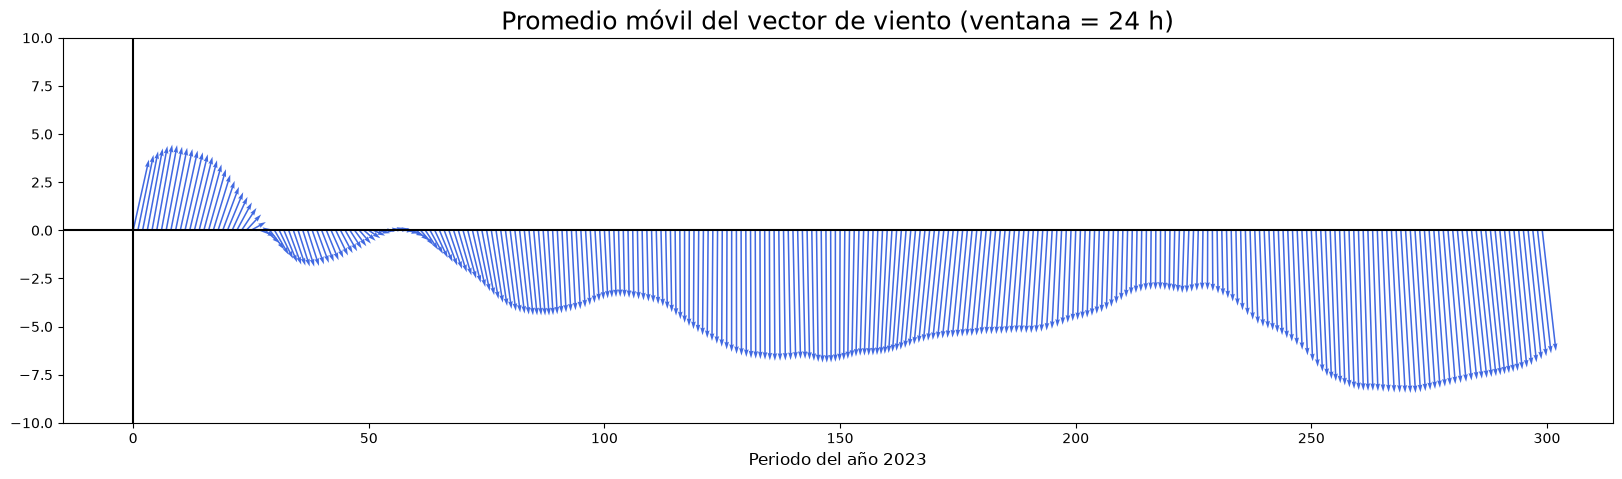

In [78]:
promedio_movil_u10 = movil(u10,24)

promedio_movil_v10 = movil(v10,24)

# creamos el vector viento.

# Notemos que el vector wind contiene 365 datos, cada componente promediada.
# Este vector esta en el sistema de referecnia N-S.

wind_movil = np.zeros((len(promedio_movil_u10),2)) 

for i in range(0,len(promedio_movil_u10)):
  wind_movil[i,0] = promedio_movil_u10[i]
  wind_movil[i,1] = promedio_movil_v10[i]

plt.figure(figsize=(20,5))

for i in range(0,300):
  plt.quiver(i,0,wind_movil[i,0],wind_movil[i,1], width = 0.001, color = 'royalblue',scale = 1, angles = 'xy', scale_units = 'xy')

plt.axhline(y = 0.0, xmin = 0.0, color = 'black')
plt.axvline(x = 0.0, ymin = 0.0, color = 'black')

# plt.grid()
plt.title("Promedio móvil del vector de viento (ventana = 24 h)", fontsize = 18)
plt.xlabel("Periodo del año 2023", fontsize = 12)

plt.ylim(-10,10)
plt.show()